# Gestion de Portefeuille - TP1

William Bourque (XXX)

Robin Dubillot (XXX)

Philippe Mondor (XXX)

Frederic Pelletier (11359258)

## Partie A

**Librairies**


In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.correlation_tools import cov_nearest
from scipy.optimize import minimize
from partieA import *
from partieB import *

**Données**

In [3]:
data = load_data('../data/48_Industry_Portfolios.csv')
industries = ['Books', 'Soda', 'FabPr', 'Steel', 'Aero']

data_last_five_years = extract_last_five_years(data, industries)
sigma = compute_sigma(data_last_five_years)

### Question 1
Construire le graphique de « mean-variance locus » (sans l’actif sans risque) de ces 5
industries. Présentez et discutez ces résultats en spécifiant chacun de 5 industries dans le
graphique.

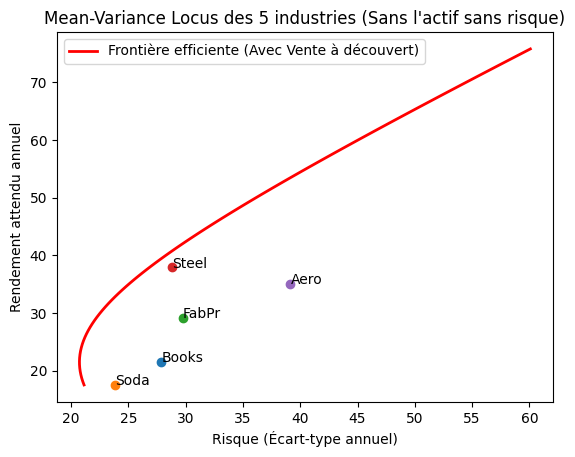

In [4]:
weights,variances,returns,mu = efficient_frontier_closed_form(data_last_five_years,sigma,annualize=True)
asset_sigmas = np.sqrt(np.diag(sigma.values * 12))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)

plt.plot(np.sqrt(variances), returns, color='red', linewidth=2, label='Frontière efficiente (Avec Vente à découvert)')
plt.legend()
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel')
plt.title("Mean-Variance Locus des 5 industries (Sans l'actif sans risque)")
plt.show()

### Question 2
Construire le graphique de « mean-variance locus » (avec l’actif sans risque) de ces 5
industries. Spécifiez chaque industrie dans le graphique. Présentez et discutez ces résultats.
Expliquez comment le « mean-variance locus » a changé avec l’actif sans risque. 

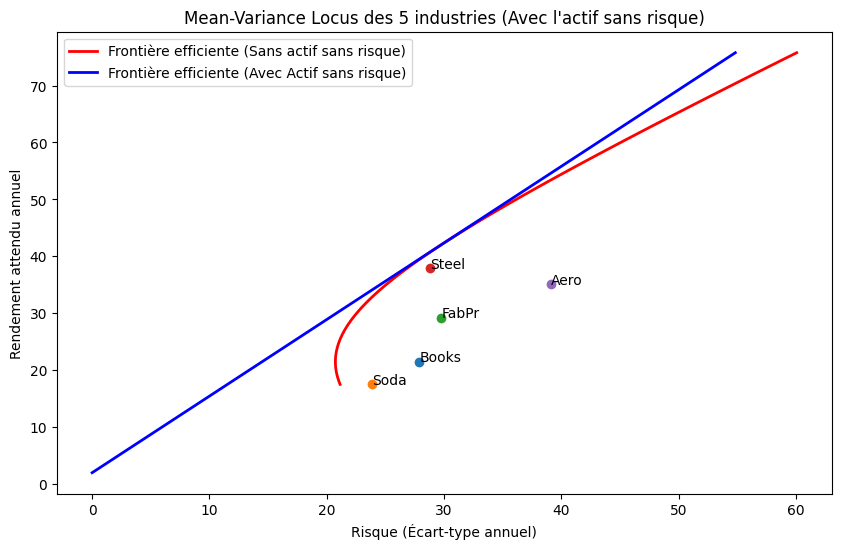

In [5]:
R = 2  # 2% risk-free rate
rf_res = mean_variance_locus_with_rfr_notes(
    data_last_five_years, sigma, n_ptf=250, R=R, annualize=True
)
plt.figure(figsize=(10, 6))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)
plt.plot(np.sqrt(variances), returns, color='red', linewidth=2, label='Frontière efficiente (Sans actif sans risque)')
plt.plot(np.sqrt(rf_res['variances']), rf_res['target_returns'], color='blue', linewidth=2, label='Frontière efficiente (Avec Actif sans risque)')
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel')
plt.title("Mean-Variance Locus des 5 industries (Avec l'actif sans risque)")
plt.legend()
plt.show()

### Question 3
Décrire le portefeuille tangent et ses caractéristiques comme sa moyenne et variance et les
poids de chaque industrie dans ce portefeuille tangent. Vérifiez numériquement que le
portefeuille tangent est le portefeuille qui maximise le ratio de Sharpe. Présentez et discutez
ces résultats.


QUESTION 3 — Portefeuille tangent (risky-only) et ratio de Sharpe
Taux sans risque R (annuel, en %): 2.000000
Somme des poids (doit être 1): 1.0000000000
Moyenne du portefeuille tangent μ_tan (%/an): 41.953440
Variance du portefeuille tangent Var_tan: 882.439901
Écart-type du portefeuille tangent σ_tan (%/an): 29.705890
Sharpe_tan = (μ_tan - R)/σ_tan: 1.344967

Poids par industrie (w_tan):
Books   -0.623010
Soda    +0.231957
FabPr   +0.164906
Steel   +1.236871
Aero    -0.010724

Vérification numérique (frontière efficiente risquée):
Sharpe maximum sur la frontière (discrétisée): 1.344936
Différence |Sharpe_max - Sharpe_tan|: 3.074387e-05

Poids du portefeuille (frontière) au Sharpe max:
Books   -0.633617
Soda    +0.227027
FabPr   +0.163749
Steel   +1.251776
Aero    -0.008935


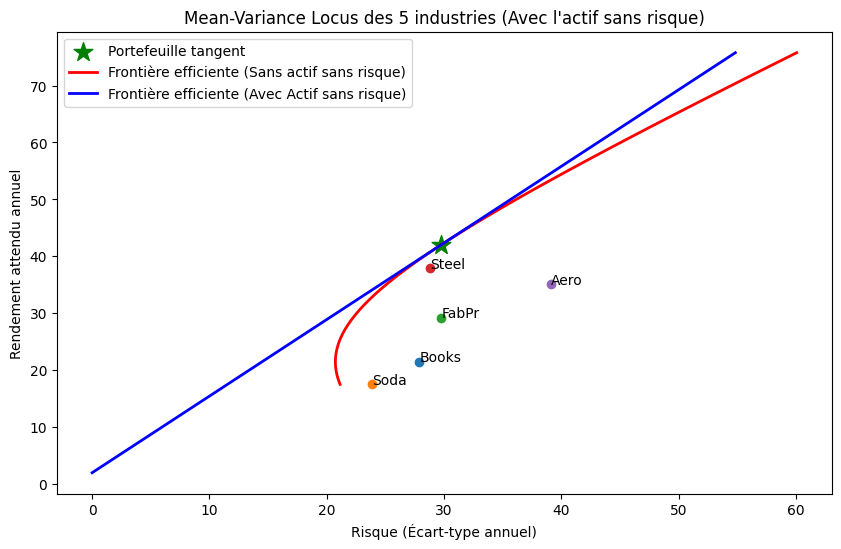

In [6]:
w_tan, mu_tan, var_tan, sig_tan, sharpe_tan = tangency_portfolio(data_last_five_years, sigma, R=R, annualize=True)

sep = "=" * 72
print(f"\n{sep}")
print("QUESTION 3 — Portefeuille tangent (risky-only) et ratio de Sharpe")
print(sep)
print(f"Taux sans risque R (annuel, en %): {R:.6f}")
print(f"Somme des poids (doit être 1): {w_tan.sum():.10f}")
print(f"Moyenne du portefeuille tangent μ_tan (%/an): {mu_tan:.6f}")
print(f"Variance du portefeuille tangent Var_tan: {var_tan:.6f}")
print(f"Écart-type du portefeuille tangent σ_tan (%/an): {sig_tan:.6f}")
print(f"Sharpe_tan = (μ_tan - R)/σ_tan: {sharpe_tan:.6f}")

print("\nPoids par industrie (w_tan):")
print(w_tan.to_string(float_format=lambda x: f"{x:+.6f}"))

sharpe_max, idx_max = verify_tangency_max_sharpe(returns, variances, R=R)
print("\nVérification numérique (frontière efficiente risquée):")
print(f"Sharpe maximum sur la frontière (discrétisée): {sharpe_max:.6f}")
print(f"Différence |Sharpe_max - Sharpe_tan|: {abs(sharpe_max - sharpe_tan):.6e}")

w_frontier_max = weights.iloc[idx_max]
w_frontier_max = w_frontier_max / w_frontier_max.sum()
print("\nPoids du portefeuille (frontière) au Sharpe max:")
print(w_frontier_max.to_string(float_format=lambda x: f"{x:+.6f}"))
print(sep)


plt.figure(figsize=(10, 6))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)
plt.scatter(sig_tan, mu_tan, color='green', marker='*', s=200, label='Portefeuille tangent')
plt.plot(np.sqrt(variances), returns, color='red', linewidth=2, label='Frontière efficiente (Sans actif sans risque)')
plt.plot(np.sqrt(rf_res['variances']), rf_res['target_returns'], color='blue', linewidth=2, label='Frontière efficiente (Avec Actif sans risque)')
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel')
plt.title("Mean-Variance Locus des 5 industries (Avec l'actif sans risque)")
plt.legend()
plt.show()


### Question 4
Construire le graphique de « mean-variance locus » (sans l’actif sans risque) avec les
contraintes de vente à découverte sur chaque industrie. Présentez et discutez ces résultats
en spécifiant chaque industrie dans le graphique. 

Text(0.5, 0, 'Risque (écart-type)')

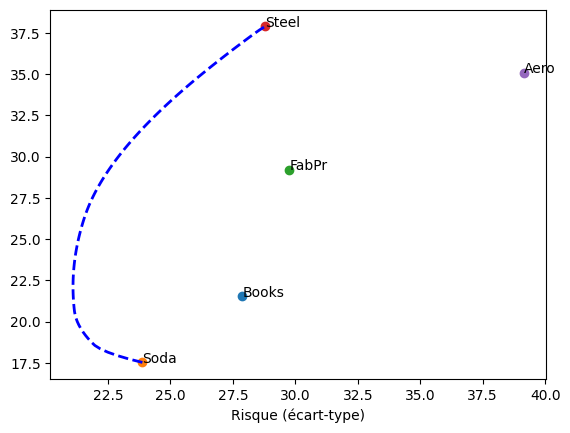

In [7]:
weights_num,variances_num,returns_num,mu_num = efficient_frontier_numerical(data_last_five_years,sigma,annualize=True,short_selling=False)
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)

plt.plot(np.sqrt(variances_num), returns_num, color='blue', linewidth=2,linestyle='--', label='Frontière efficiente (Sans Vente à découvert)')
plt.xlabel('Risque (écart-type)')


### Question 5

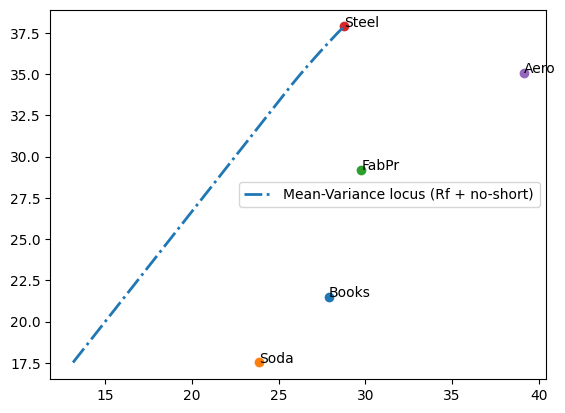

In [8]:
R = 0
weights_noshort, variances_noshort, rets_noshort, mu_noshort = efficient_frontier_with_rfr_noshort(
data_last_five_years, sigma, R, n_ptf=250, annualize=True
)

sig_q5 = np.sqrt(np.array(variances_noshort))
mu_q5 = np.array(rets_noshort)[:len(sig_q5)]

plt.plot(sig_q5, mu_q5, linestyle='-.', linewidth=2,
        label='Mean-Variance locus (Rf + no-short)')

for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)
    

plt.legend()
plt.show()

### Question 6

In [9]:
R = 0.0
mu_assets = data_last_five_years.mean().values * 12
Sigma_assets = sigma.values * 12

w_star, mu_p, var_p, sharpe_p = tangency_portfolio_noshort(mu_assets, Sigma_assets, R)

print("\n================ Q6: Tangency (Rf=0, no-short) ================")
print("Poids du portefeuille tangent (long-only):")
for name, w in zip(industries, w_star):
    print(f"  {name}: {w:.4f}")
print(f"Moyenne (mu_p): {mu_p:.6f}")
print(f"Variance (var_p): {var_p:.6f}")
print(f"Ecart-type (sigma_p): {np.sqrt(var_p):.6f}")
print(f"Sharpe (mu_p - R)/sigma_p: {sharpe_p:.6f}")

max_sharpe_rand, w_best_rand = verify_max_sharpe_random(mu_assets, Sigma_assets, R, n_random=20000, seed=0)
print(f"Max Sharpe (random long-only, n=20000): {max_sharpe_rand:.6f}")
print(f"Diff (tangency - random max): {sharpe_p - max_sharpe_rand:.6e}")


================ Q6: Tangency (Rf=0, no-short) ================
Poids du portefeuille tangent (long-only):
  Books: 0.0000
  Soda: 0.1554
  FabPr: 0.0985
  Steel: 0.7461
  Aero: 0.0000
Moyenne (mu_p): 33.864532
Variance (var_p): 644.148397
Ecart-type (sigma_p): 25.380079
Sharpe (mu_p - R)/sigma_p: 1.334296
Max Sharpe (random long-only, n=20000): 1.331935
Diff (tangency - random max): 2.360309e-03


# Partie B

### Question 2

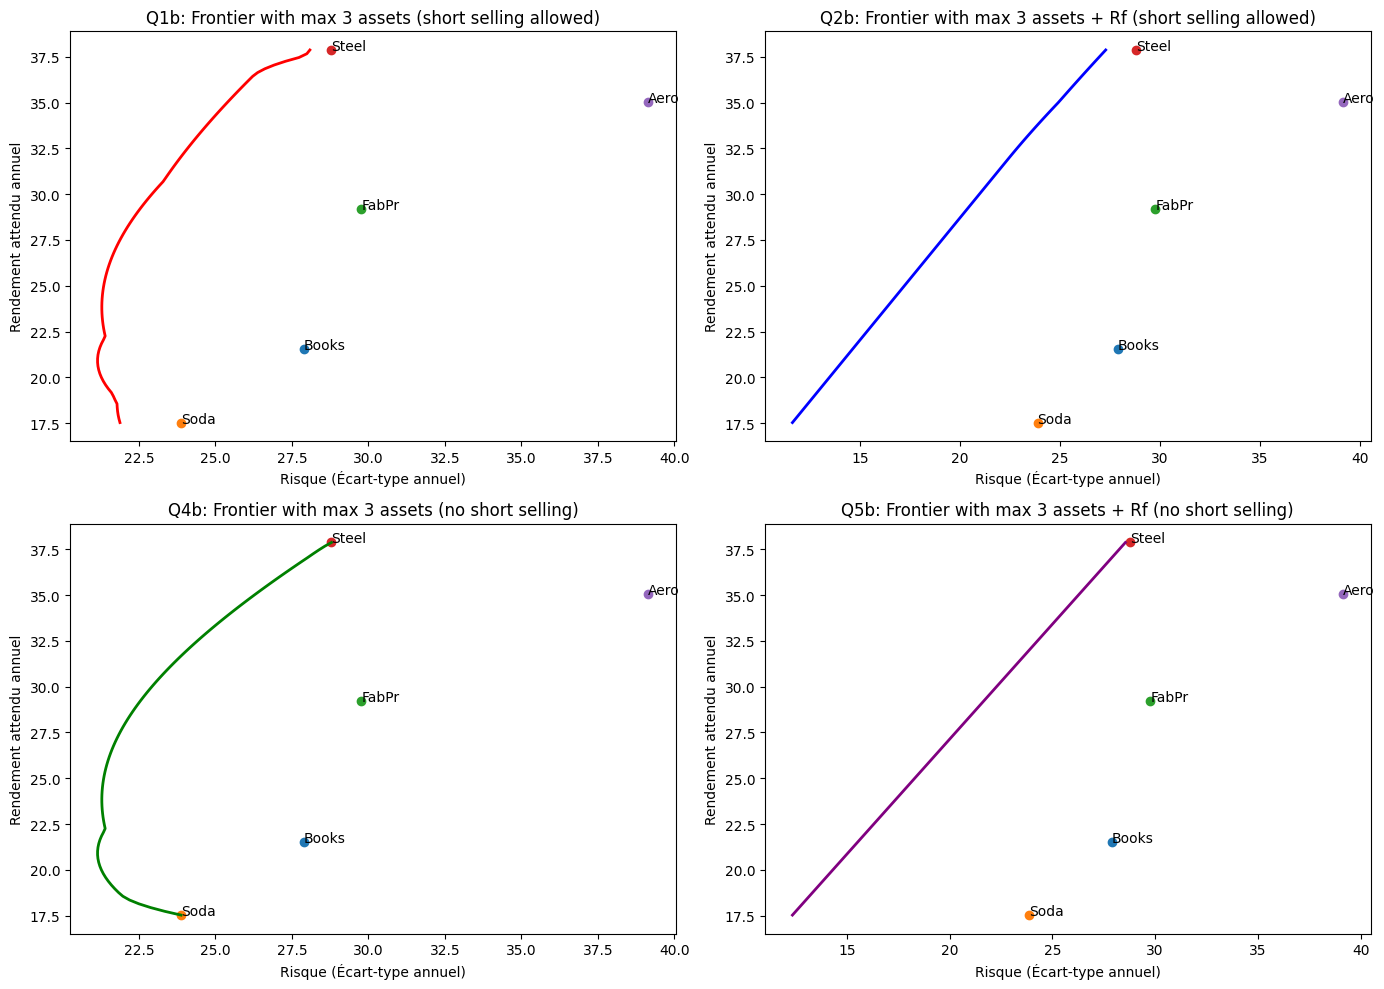


================ Q3b: Tangency with max 3 assets (short selling allowed) ================
Taux sans risque R (annuel, en %): 2.000000
Somme des poids (doit être 1): 1.0000000000

Poids par industrie (w_tan_3b):
  Books: -0.308819
  Soda: 0.308819
  FabPr: 0.000000
  Steel: 1.000000
  Aero: 0.000000
Moyenne du portefeuille tangent μ_tan (%/an): 36.648763
Variance du portefeuille tangent Var_tan: 696.016171
Écart-type du portefeuille tangent σ_tan (%/an): 26.382118
Sharpe_tan = (μ_tan - R)/σ_tan: 1.313343

Vérification numérique (frontière efficiente risquée):
Sharpe maximum sur la frontière (discrétisée): 1.313636
Différence |Sharpe_max - Sharpe_tan|: 2.935554e-04

================ Q6b: Tangency with max 3 assets (no short selling) ================
Taux sans risque R (annuel, en %): 2.000000
Somme des poids (doit être 1): 1.0000000000

Poids par industrie (w_q6b):
  Books: 0.000000
  Soda: 0.113960
  FabPr: 0.088072
  Steel: 0.797969
  Aero: 0.000000
Moyenne du portefeuille tangent μ_t

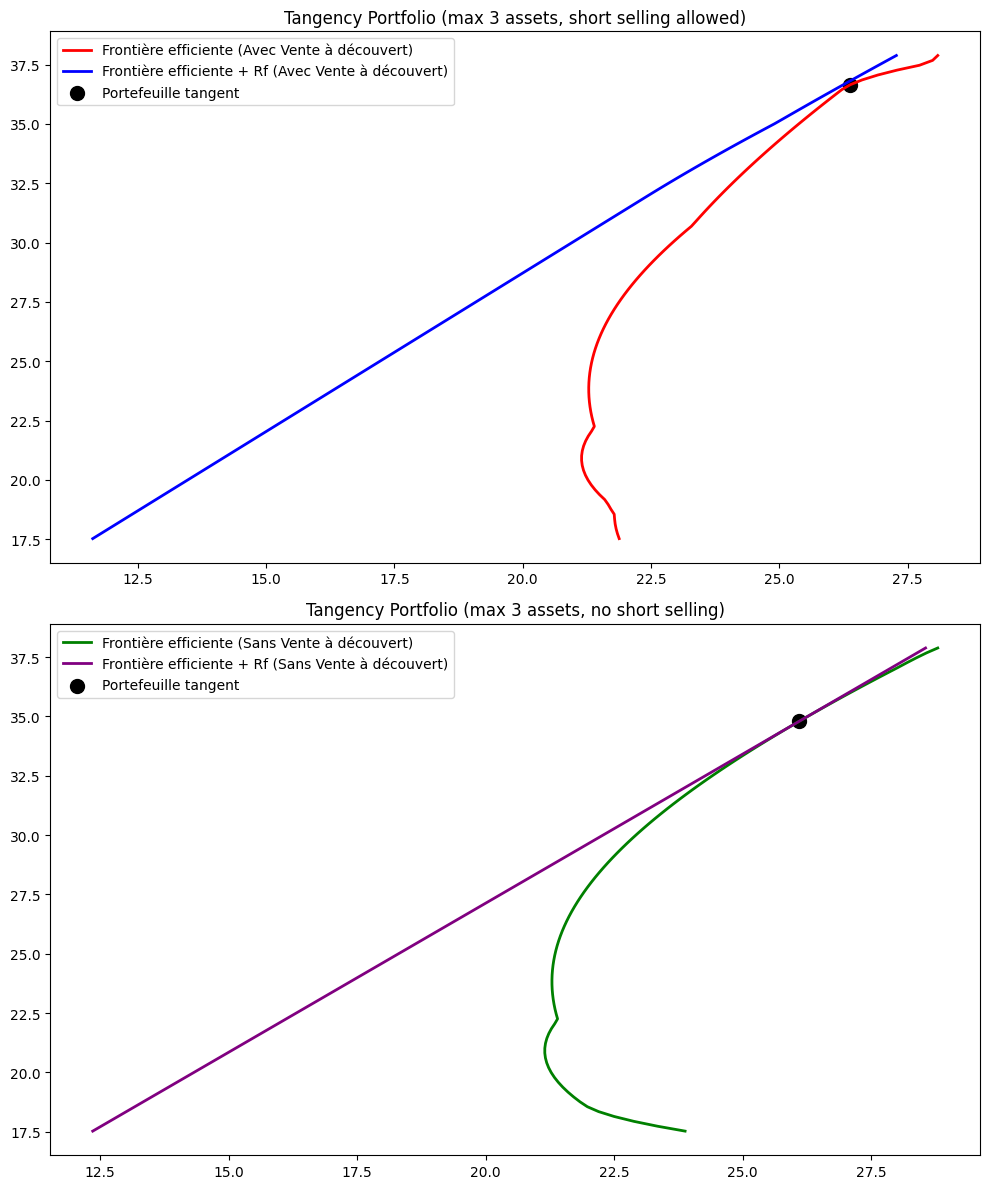

In [148]:
from partieB import *
R = 2
#we repeat question 1 to 6 with max 3 assets
weights_q1b,variances_q1b,returns_q1b,mu_q1b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=True,max_asset=3)
weights_q2b, variances_q2b, returns_q2b, mu_q2b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=True,max_asset=3, rf = R)

risky_frontier_3b = {
    'variance': np.array(variances_q1b),
    'return': np.array(returns_q1b),
    'weights': weights_q1b
}
riskless_frontier_3b = {
    'variance': np.array(variances_q2b),
    'return': np.array(returns_q2b),
    'weights': weights_q2b
}
weights_tan_3b, var_tan_3b, ret_tan_3b, sharpe_tan_3b = tangency_portfolio_heuristic(risky_frontier_3b, riskless_frontier_3b, R)




weights_q4b, variances_q4b, returns_q4b, mu_q4b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=False,max_asset=3)
weights_q5b, variances_q5b, returns_q5b, mu_q5b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=False,max_asset=3, rf = R)

risky_frontier_q6b = {
    'variance': np.array(variances_q4b),
    'return': np.array(returns_q4b),
    'weights': weights_q4b
}
riskless_frontier_q6b = {
    'variance': np.array(variances_q5b),
    'return': np.array(returns_q5b),
    'weights': weights_q5b
}
weights_q6b, var_q6b, ret_q6b, sharpe_q6b = tangency_portfolio_heuristic(risky_frontier_q6b, riskless_frontier_q6b, R)


#we plot the results in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs[0, 0].set_title("Q1b: Frontier with max 3 assets (short selling allowed)")
axs[0, 0].plot(np.sqrt(variances_q1b), returns_q1b, color='red', linewidth=2)
axs[0, 1].set_title("Q2b: Frontier with max 3 assets + Rf (short selling allowed)")
axs[0, 1].plot(np.sqrt(variances_q2b), returns_q2b, color='blue', linewidth=2)
axs[1, 0].set_title("Q4b: Frontier with max 3 assets (no short selling)")
axs[1, 0].plot(np.sqrt(variances_q4b), returns_q4b, color='green', linewidth=2)
axs[1, 1].set_title("Q5b: Frontier with max 3 assets + Rf (no short selling)")
axs[1, 1].plot(np.sqrt(variances_q5b), returns_q5b, color='purple', linewidth=2)
for i, industry in enumerate(industries):
    asset_sigma = np.sqrt(sigma.values[i] * 12)
    mu_asset = mu[i]
    for ax in axs.flatten():
        ax.scatter(asset_sigma[i], mu_asset)
        ax.text(asset_sigma[i], mu_asset, industry)
for ax in axs.flatten():
    ax.set_xlabel('Risque (Écart-type annuel)')
    ax.set_ylabel('Rendement attendu annuel')
plt.tight_layout()
plt.show()

print("\n================ Q3b: Tangency with max 3 assets (short selling allowed) ================")
print(f"Taux sans risque R (annuel, en %): {R:.6f}")
print(f"Somme des poids (doit être 1): {weights_tan_3b.sum():.10f}")
print(f"\nPoids par industrie (w_tan_3b):")
for industry, weight in weights_tan_3b.items():
    print(f"  {industry}: {weight:.6f}")
print(f"Moyenne du portefeuille tangent μ_tan (%/an): {ret_tan_3b:.6f}")
print(f"Variance du portefeuille tangent Var_tan: {var_tan_3b:.6f}")
print(f"Écart-type du portefeuille tangent σ_tan (%/an): {np.sqrt(var_tan_3b):.6f}")
print(f"Sharpe_tan = (μ_tan - R)/σ_tan: {sharpe_tan_3b:.6f}")

sharpe_max, idx_max = verify_tangency_max_sharpe(returns_q1b, variances_q1b, R=R)
print("\nVérification numérique (frontière efficiente risquée):")
print(f"Sharpe maximum sur la frontière (discrétisée): {sharpe_max:.6f}")
print(f"Différence |Sharpe_max - Sharpe_tan|: {abs(sharpe_max - sharpe_tan_3b):.6e}")



print("\n================ Q6b: Tangency with max 3 assets (no short selling) ================")
print(f"Taux sans risque R (annuel, en %): {R:.6f}")
print(f"Somme des poids (doit être 1): {weights_q6b.sum():.10f}")
print(f"\nPoids par industrie (w_q6b):")
for industry, weight in weights_q6b.items():
    print(f"  {industry}: {weight:.6f}")
print(f"Moyenne du portefeuille tangent μ_tan (%/an): {ret_q6b:.6f}")
print(f"Variance du portefeuille tangent Var_tan: {var_q6b:.6f}")
print(f"Écart-type du portefeuille tangent σ_tan (%/an): {np.sqrt(var_q6b):.6f}")
print(f"Sharpe_tan = (μ_tan - R)/σ_tan: {sharpe_q6b:.6f}")


sharpe_max, idx_max = verify_tangency_max_sharpe(returns_q4b, variances_q4b, R=R)
print("\nVérification numérique (frontière efficiente risquée):")
print(f"Sharpe maximum sur la frontière (discrétisée): {sharpe_max:.6f}")
print(f"Différence |Sharpe_max - Sharpe_tan|: {abs(sharpe_max - sharpe_q6b):.6e}")

#plotting the tangency portfolios found in Q3b and Q6b on the previous frontier plots in a 2x1 grid
fig, axs = plt.subplots(2, 1, figsize=(10, 12))
axs[0].set_title("Tangency Portfolio (max 3 assets, short selling allowed)")
axs[0].plot(np.sqrt(variances_q1b), returns_q1b, color='red', linewidth=2, label='Frontière efficiente (Avec Vente à découvert)')
axs[0].plot(np.sqrt(variances_q2b), returns_q2b, color='blue', linewidth=2, label='Frontière efficiente + Rf (Avec Vente à découvert)')
axs[0].scatter(np.sqrt(var_tan_3b), ret_tan_3b, color='black', s=100, label='Portefeuille tangent')
axs[0].legend()

axs[1].set_title("Tangency Portfolio (max 3 assets, no short selling)")
axs[1].plot(np.sqrt(variances_q4b), returns_q4b, color='green', linewidth=2, label='Frontière efficiente (Sans Vente à découvert)')
axs[1].plot(np.sqrt(variances_q5b), returns_q5b, color='purple', linewidth=2, label='Frontière efficiente + Rf (Sans Vente à découvert)')
axs[1].scatter(np.sqrt(var_q6b), ret_q6b, color='black', s=100, label='Portefeuille tangent')
axs[1].legend()
plt.tight_layout()
plt.show()